In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

In [18]:
def solve_cat_problem_v3(
    T,
    a,
    b,
    c,
    d,
    rl,
    ry,
    Il,
    Iy,
    h,
    alpha,
    beta,
    k_hat,
    umax,
    n=200,
    animate=True,
    saveplots=False,
    saveanim=False
):
    """
    Solves the cat problem with an external hat torque, terminal penalty, and bounded control.

    Minimize
        J[u] = ∫_0^T (K(t) + h u(t)^2) dt
            + alpha * theta(T)^2
            + beta * theta_dot(T)^2

    subject to
        |u(t)| <= umax

    with dynamics
        theta'     = theta_dot
        theta_dot' = (-Il*u - k_hat*v(t)*sin(theta)) / (Iy + Il)
        phi'       = phi_dot
        phi_dot'   = u

    where
        v(t) = 4.9 t

    and
        K(t) = 0.5*Iy*theta_dot^2 + 0.5*Il*(theta_dot + phi_dot)^2

    Boundary conditions:
        theta(0)     = a
        theta_dot(0) = c
        phi(0)       = b
        phi_dot(0)   = d

    Terminal transversality conditions:
        p1(T) = 2 * alpha * theta(T)
        p2(T) = 2 * beta * theta_dot(T)
        p3(T) = 0
        p4(T) = 0

    Notes:
        - theta(T) and theta_dot(T) are not enforced exactly.
        - Instead, the terminal penalty encourages them to be small.
        - The control bound |u(t)| <= umax is enforced through clipping of the unconstrained optimal control.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.integrate import solve_bvp
    from matplotlib.animation import FuncAnimation
    from IPython.display import display, HTML

    denom = Iy + Il

    def v_fall(t):
        return 4.9 * t

    def u_star(p2, p4):
        u_unc = ((Il / denom) * p2 - p4) / (2 * h)
        return np.clip(u_unc, -umax, umax)

    # -----------------------------
    # ODE system
    # Y = [theta, theta_dot, phi, phi_dot, p1, p2, p3, p4]
    # -----------------------------
    def ode_system(t, Y):
        theta = Y[0]
        theta_dot = Y[1]
        phi = Y[2]
        phi_dot = Y[3]
        p1 = Y[4]
        p2 = Y[5]
        p3 = Y[6]
        p4 = Y[7]

        u = u_star(p2, p4)
        v = v_fall(t)

        return np.vstack([
            theta_dot,
            (-Il * u - k_hat * v * np.sin(theta)) / denom,
            phi_dot,
            u,
            (k_hat * v * np.cos(theta) / denom) * p2,
            -((Iy + Il) * theta_dot + Il * phi_dot + p1),
            np.zeros_like(t),
            -(Il * (theta_dot + phi_dot) + p3)
        ])

    # -----------------------------
    # Boundary conditions
    # -----------------------------
    def boundary_conditions(Ya, Yb):
        return np.array([
            Ya[0] - a,                    # theta(0) = a
            Ya[1] - c,                    # theta_dot(0) = c
            Ya[2] - b,                    # phi(0) = b
            Ya[3] - d,                    # phi_dot(0) = d
            Yb[4] - 2 * alpha * Yb[0],    # p1(T) = 2 alpha theta(T)
            Yb[5] - 2 * beta * Yb[1],     # p2(T) = 2 beta theta_dot(T)
            Yb[6],                        # p3(T) = 0
            Yb[7],                        # p4(T) = 0
        ])

    # -----------------------------
    # Initial guess
    # -----------------------------
    t_grid = np.linspace(0, T, n)

    # cubic guess for theta from (a,c) to (0,0)
    A = a
    B = c
    C = (-3 * a - 2 * c * T) / T**2
    D = (2 * a + c * T) / T**3

    theta_guess = A + B * t_grid + C * t_grid**2 + D * t_grid**3
    theta_dot_guess = B + 2 * C * t_grid + 3 * D * t_grid**2

    # simple guess for phi
    phi_guess = b + d * t_grid
    phi_dot_guess = d * np.ones_like(t_grid)

    Y_guess = np.zeros((8, t_grid.size))
    Y_guess[0] = theta_guess
    Y_guess[1] = theta_dot_guess
    Y_guess[2] = phi_guess
    Y_guess[3] = phi_dot_guess
    Y_guess[4] = 0.0
    Y_guess[5] = 0.0
    Y_guess[6] = 0.0
    Y_guess[7] = 0.0

    solution = solve_bvp(
        ode_system,
        boundary_conditions,
        t_grid,
        Y_guess,
        tol=1e-5,
        max_nodes=20000,
        verbose=2
    )

    if not solution.success:
        print("Warning: solve_bvp did not report convergence.")
        print(solution.message)

    # -----------------------------
    # Extract solution
    # -----------------------------
    t_vals = solution.x
    theta_vals = solution.y[0]
    theta_dot_vals = solution.y[1]
    phi_vals = solution.y[2]
    phi_dot_vals = solution.y[3]
    p1_vals = solution.y[4]
    p2_vals = solution.y[5]
    p3_vals = solution.y[6]
    p4_vals = solution.y[7]

    control_vals = u_star(p2_vals, p4_vals)
    v_vals = v_fall(t_vals)

    tail_abs_dot_vals = theta_dot_vals + phi_dot_vals

    kinetic_energy_vals = (
        0.5 * Iy * theta_dot_vals**2
        + 0.5 * Il * tail_abs_dot_vals**2
    )

    hat_torque_vals = -k_hat * v_vals * np.sin(theta_vals)
    running_cost_val = np.trapezoid(kinetic_energy_vals + h * control_vals**2, t_vals)

    # -----------------------------
    # Plot helper
    # -----------------------------
    def maybe_save(fig, filename):
        if saveplots:
            fig.savefig(filename, dpi=300, bbox_inches="tight")

    # theta(t)
    fig_theta, ax_theta = plt.subplots()
    ax_theta.plot(t_vals, theta_vals)
    ax_theta.set_title(r"$\theta(t)$")
    ax_theta.set_xlabel("t")
    ax_theta.set_ylabel(r"$\theta$")
    maybe_save(fig_theta, "theta_plot_v3.png")
    plt.show()

    # phi(t)
    fig_phi, ax_phi = plt.subplots()
    ax_phi.plot(t_vals, phi_vals)
    ax_phi.set_title(r"$\phi(t)$")
    ax_phi.set_xlabel("t")
    ax_phi.set_ylabel(r"$\phi$")
    maybe_save(fig_phi, "phi_plot_v3.png")
    plt.show()

    # theta_dot(t)
    fig_theta_dot, ax_theta_dot = plt.subplots()
    ax_theta_dot.plot(t_vals, theta_dot_vals)
    ax_theta_dot.set_title(r"$\dot{\theta}(t)$")
    ax_theta_dot.set_xlabel("t")
    ax_theta_dot.set_ylabel(r"$\dot{\theta}$")
    maybe_save(fig_theta_dot, "theta_dot_plot_v3.png")
    plt.show()

    # phi_dot(t)
    fig_phi_dot, ax_phi_dot = plt.subplots()
    ax_phi_dot.plot(t_vals, phi_dot_vals)
    ax_phi_dot.set_title(r"$\dot{\phi}(t)$")
    ax_phi_dot.set_xlabel("t")
    ax_phi_dot.set_ylabel(r"$\dot{\phi}$")
    maybe_save(fig_phi_dot, "phi_dot_plot_v3.png")
    plt.show()

    # u(t)
    fig_control, ax_control = plt.subplots()
    ax_control.plot(t_vals, control_vals)
    ax_control.axhline(umax, linestyle="--")
    ax_control.axhline(-umax, linestyle="--")
    ax_control.set_title(r"$u(t)=\ddot{\phi}(t)$")
    ax_control.set_xlabel("t")
    ax_control.set_ylabel("u")
    maybe_save(fig_control, "control_plot_v3.png")
    plt.show()

    # K(t)
    fig_kinetic, ax_kinetic = plt.subplots()
    ax_kinetic.plot(t_vals, kinetic_energy_vals)
    ax_kinetic.set_title(r"$K(t)$")
    ax_kinetic.set_xlabel("t")
    ax_kinetic.set_ylabel("K")
    maybe_save(fig_kinetic, "kinetic_energy_plot_v3.png")
    plt.show()

    # hat torque
    fig_torque, ax_torque = plt.subplots()
    ax_torque.plot(t_vals, hat_torque_vals)
    ax_torque.set_title(r"$\tau_{\mathrm{hat}}(t)$")
    ax_torque.set_xlabel("t")
    ax_torque.set_ylabel(r"$\tau_{\mathrm{hat}}$")
    maybe_save(fig_torque, "hat_torque_plot_v3.png")
    plt.show()

    # -----------------------------
    # Animation
    # -----------------------------
    animation_object = None

    if animate:
        max_frames = 120
        frame_stride = max(1, len(t_vals) // max_frames)

        t_anim = t_vals[::frame_stride]
        theta_anim = theta_vals[::frame_stride]
        phi_anim = phi_vals[::frame_stride]

        fig_anim, ax_anim = plt.subplots(figsize=(5, 5))
        ax_anim.set_xlim(-2.2, 2.2)
        ax_anim.set_ylim(-2.2, 2.2)
        ax_anim.set_aspect("equal")
        ax_anim.set_title("Courtney Animation")

        body_patch = plt.Circle((0, 0), 1.0, fill=True, color="saddlebrown", alpha=0.8)
        ax_anim.add_patch(body_patch)

        eye_left_plot, = ax_anim.plot([], [], "o", markersize=4, color="black")
        eye_right_plot, = ax_anim.plot([], [], "o", markersize=4, color="black")
        mouth_plot, = ax_anim.plot([], [], lw=2, color="red")
        hat_brim_plot, = ax_anim.plot([], [], lw=7, color="black")
        hat_top_plot, = ax_anim.plot([], [], lw=10, color="black")
        tail_plot, = ax_anim.plot([], [], lw=3, color="black")

        tail_length = rl

        ground_line, = ax_anim.plot([], [], lw=3, color="green")

        g_ground = 21.44
        ground_y0 = -0.82 - 0.5 * g_ground * T**2
        x_ground = np.array([-3.0, 3.0])

        def update(frame_index):
            theta = theta_anim[frame_index]
            phi = phi_anim[frame_index]

            rotation_matrix = np.array([
                [np.cos(theta), -np.sin(theta)],
                [np.sin(theta),  np.cos(theta)]
            ])

            body_up = rotation_matrix @ np.array([0.0, 1.0])
            body_right = rotation_matrix @ np.array([1.0, 0.0])

            left_eye = rotation_matrix @ np.array([-0.18, 0.15])
            right_eye = rotation_matrix @ np.array([0.18, 0.15])
            eye_left_plot.set_data([left_eye[0]], [left_eye[1]])
            eye_right_plot.set_data([right_eye[0]], [right_eye[1]])

            smile_s = np.linspace(-1.0, 1.0, 30)
            smile_local = np.vstack([
                0.12 * smile_s,
                -0.18 + 0.04 * smile_s**2
            ])
            smile_points = rotation_matrix @ smile_local
            mouth_plot.set_data(smile_points[0], smile_points[1])

            hat_center = 1.02 * body_up
            hat_half_width = 0.45
            hat_height = 0.14

            brim_left = hat_center - hat_half_width * body_right
            brim_right = hat_center + hat_half_width * body_right
            hat_brim_plot.set_data(
                [brim_left[0], brim_right[0]],
                [brim_left[1], brim_right[1]]
            )

            top_center = hat_center + hat_height * body_up
            top_left = top_center - 0.16 * body_right
            top_right = top_center + 0.16 * body_right
            hat_top_plot.set_data(
                [top_left[0], top_right[0]],
                [top_left[1], top_right[1]]
            )

            tail_absolute_angle = theta + phi + np.pi/2
            tail_base = np.array([0.0, 0.0])
            tail_tip = tail_length * np.array([
                np.cos(tail_absolute_angle),
                np.sin(tail_absolute_angle)
            ])

            tail_plot.set_data(
                [tail_base[0], tail_tip[0]],
                [tail_base[1], tail_tip[1]]
            )

            t_current = t_anim[frame_index]
            ground_y = ground_y0 + 0.5 * g_ground * t_current**2
            ground_line.set_data(x_ground, [ground_y, ground_y])

            return (
                eye_left_plot,
                eye_right_plot,
                mouth_plot,
                hat_brim_plot,
                hat_top_plot,
                tail_plot,
                ground_line,
            )

        n_frames = len(theta_anim)
        interval = (T / max(n_frames, 1)) * 1000

        animation_object = FuncAnimation(
            fig_anim,
            update,
            frames=n_frames,
            interval=interval,
            blit=True
        )

        maybe_save(fig_anim, "cat_animation_first_frame_v3.png")

        if saveanim:
            from matplotlib.animation import FFMpegWriter
            fps = max(1, int(n_frames / T))
            writer = FFMpegWriter(fps=fps, bitrate=1800)
            animation_object.save("cat_animation_v3.mp4", writer=writer)

        video = animation_object.to_html5_video()
        video = video.replace("loop", "")
        display(HTML(video))
        plt.close(fig_anim)

    return {
        "solution": solution,
        "t": t_vals,
        "theta": theta_vals,
        "theta_dot": theta_dot_vals,
        "phi": phi_vals,
        "phi_dot": phi_dot_vals,
        "p1": p1_vals,
        "p2": p2_vals,
        "p3": p3_vals,
        "p4": p4_vals,
        "u": control_vals,
        "K": kinetic_energy_vals,
        "hat_torque": hat_torque_vals,
        "running_cost": running_cost_val,
    }

In [19]:
T = 1.7
a = np.pi
b = 0
c = 0
d = 0

m = 1.0      # tail-end mass
M = 20.0     # body mass
rl = 1.5     # tail length
ry = 1.0     # body radius

Il = m * rl**2
Iy = 0.5 * M * ry**2

h = 1.0
alpha=1000
beta=200
umax=6*np.pi

khat=np.pi

   Iteration    Max residual  Max BC residual  Total nodes    Nodes added  
       1          1.88e-01       5.68e-14          200            398      
       2          3.39e-04       1.30e-23          598             2       
       3          1.98e-04       1.71e-13          600             2       
       4          5.44e-05       2.84e-13          602             2       
       5          3.67e-05       5.68e-14          604             2       
       6          3.11e-05       5.68e-14          606             2       
       7          7.50e-06       2.14e-24          608             0       
Solved in 7 iterations, number of nodes 608. 
Maximum relative residual: 7.50e-06 
Maximum boundary residual: 2.14e-24


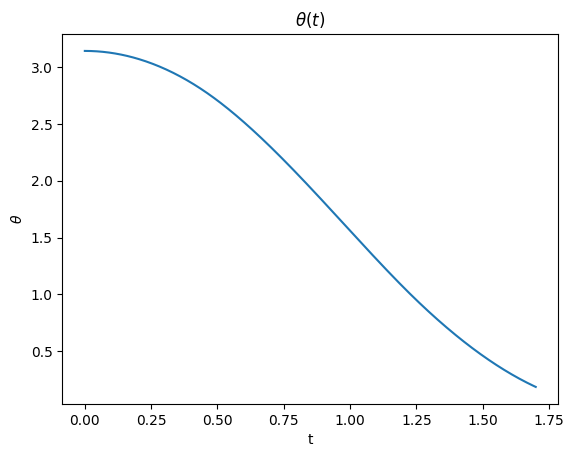

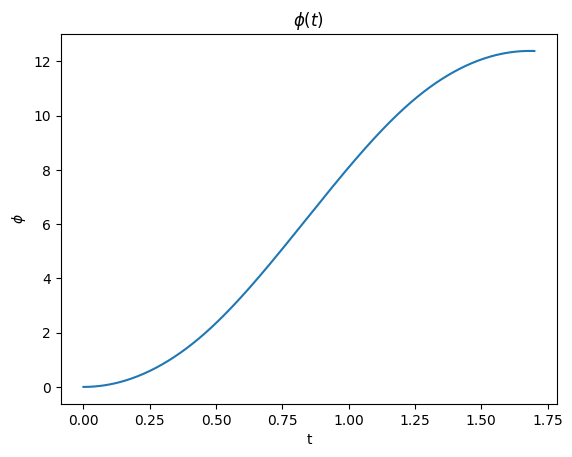

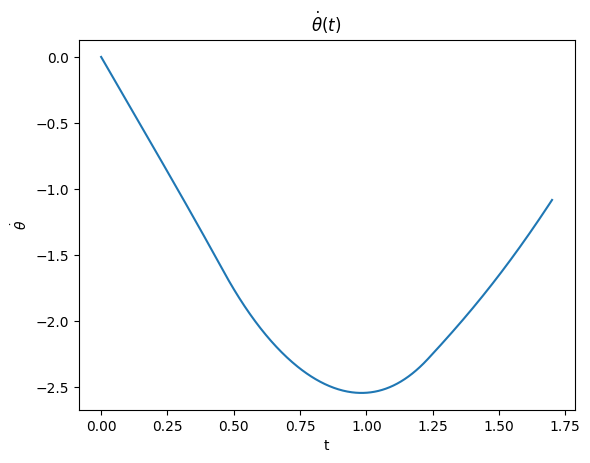

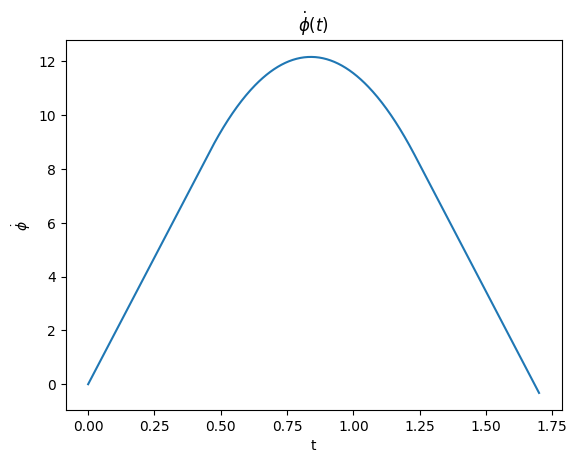

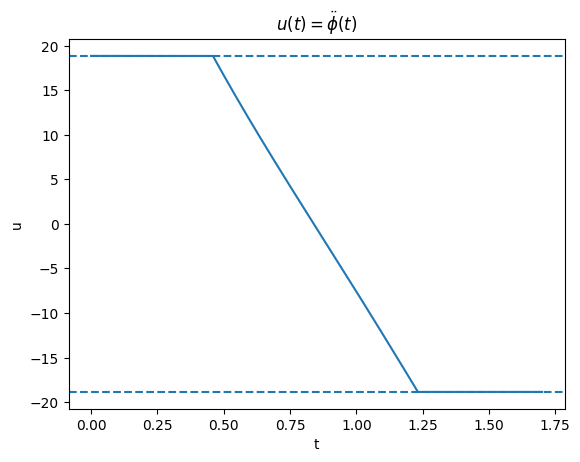

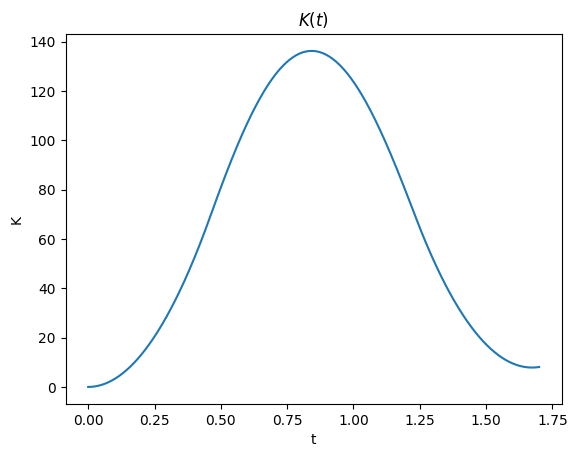

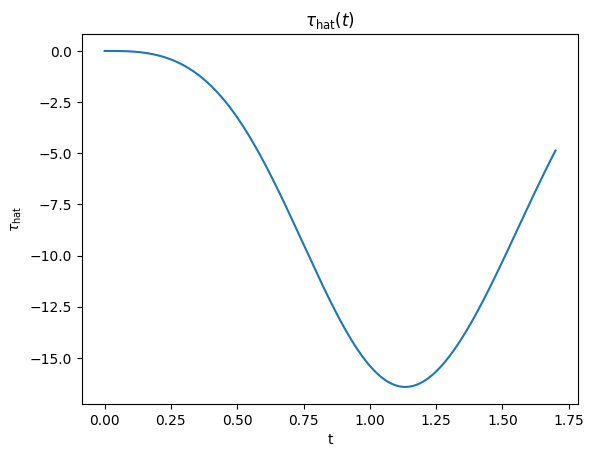

{'solution':        message: The algorithm converged to the desired accuracy.
        success: True
         status: 0
              x: [ 0.000e+00  2.848e-03 ...  1.697e+00  1.700e+00]
            sol: <scipy.interpolate._interpolate.PPoly object at 0x1455d4e90>
              p: None
              y: [[ 3.142e+00  3.142e+00 ...  1.902e-01  1.871e-01]
                  [ 0.000e+00 -9.859e-03 ... -1.091e+00 -1.082e+00]
                  ...
                  [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
                  [ 2.121e+01  2.121e+01 ... -8.864e-03  0.000e+00]]
             yp: [[ 0.000e+00 -9.859e-03 ... -1.091e+00 -1.082e+00]
                  [-3.462e+00 -3.462e+00 ...  3.059e+00  3.065e+00]
                  ...
                  [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
                  [-3.076e-24 -9.859e-02 ...  3.062e+00  3.163e+00]]
  rms_residuals: [ 6.329e-10  7.059e-10 ...  1.343e-09  1.335e-09]
          niter: 7,
 't': array([0.        , 0.00284757, 

In [20]:
solve_cat_problem_v3(
    T,
    a,
    b,
    c,
    d,
    rl,
    ry,
    Il,
    Iy,
    h,
    k_hat=khat,
    alpha=alpha,
    beta=beta,
    umax=umax,
    n=200,
    animate=True,
    saveplots=True,
    saveanim=True
)